In [52]:
# --- 4.2 Importing Data ---

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [54]:
df = pd.read_csv('exoplanet_data.csv', comment='#')

In [55]:
print(f"Shape of the dataset: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\nColumn Titles:")
print(df.columns.tolist())
# 5 column titles: 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim'

Shape of the dataset: (583, 92)
Rows: 583
Columns: 92

Column Titles:
['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 

In [56]:
# --- 4.3 Reducing Data ---

In [57]:
# 1. Table Label: Planet Name
# Database Column Name: pl_name
# Description: Full name of the planetary candidate.
# My Words: This is the specific "ID" or name given to the planet, usually based on its star.

# 2. Table Label: Host Name
# Database Column Name: hostname
# Description: Stellar name of the host star.
# My Words: The name of the star that the planet is orbiting around.

# 3. Table Label: Discovery Method
# Database Column Name: discoverymethod
# Description: Method by which the planet was first identified.
# My Words: The scientific technique (like watching it pass in front of a star) used to find it.

# 4. Table Label: Spectral Type
# Database Column Name: st_spectype
# Description: Classification of the star based on its spectrum (color/temperature).
# My Words: A code (like 'G2V') that tells us if the star is like our Sun, or bigger, smaller, or a different color.

# 5. Table Label: Equilibrium Temperature [K]
# Database Column Name: pl_eqt
# Description: The theoretical temperature of the planet (in Kelvin) assuming it's a blackbody.
# My Words: How hot the planet's surface is likely to be based on how close it is to its sun.

# 6. Table Label: Planet Mass or Mass*sin(i) [Jupiter Mass]
# Database Column Name: pl_bmassj
# Description: The best estimate of the planet's mass, measured in units of Jupiter's mass.
# My Words: How heavy the planet is compared to Jupiter; used to see if it's a gas giant or rocky.

In [58]:
target_columns = ['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']
df_small = df[target_columns]
df_reduced = df_small.dropna()

In [59]:
print(f"Shape of the reduced dataset: {df_reduced.shape}")

print(f"Number of rows: {df_reduced.shape[0]}")
print(f"Number of columns: {df_reduced.shape[1]}")

print("\nFirst five rows:")
display(df_reduced.head())

print("\nLast five rows:")
display(df_reduced.tail())

print("\nFinal Column Titles:")
print(df_reduced.columns.tolist())

Shape of the reduced dataset: (70, 6)
Number of rows: 70
Number of columns: 6

First five rows:


,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
3,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
5,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
7,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
8,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
10,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000



Last five rows:


,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
562,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
565,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
569,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
572,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
581,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310



Final Column Titles:
['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']


In [60]:
# --- 4.4 Analyze Data ---

In [61]:
method_counts = df_reduced['discoverymethod'].value_counts()
print("Discovery Methods and Counts:")
print(method_counts)

print(f"\nMost common method: {method_counts.idxmax()} ({method_counts.max()} planets)")
print(f"Least common method: {method_counts.idxmin()} ({method_counts.min()} planets)")

# Transit: Watching a star for a tiny dip in brightness, which happens when a planet passes in front of the star and blocks some light.
# Radial Velocity: Looking for a star wobbling back and forth due to the gravity of an orbiting planet pulling on the star.
# Imaging: Taking an actual picture of the planet. 

Discovery Methods and Counts:
discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

Most common method: Transit (55 planets)
Least common method: Imaging (2 planets)


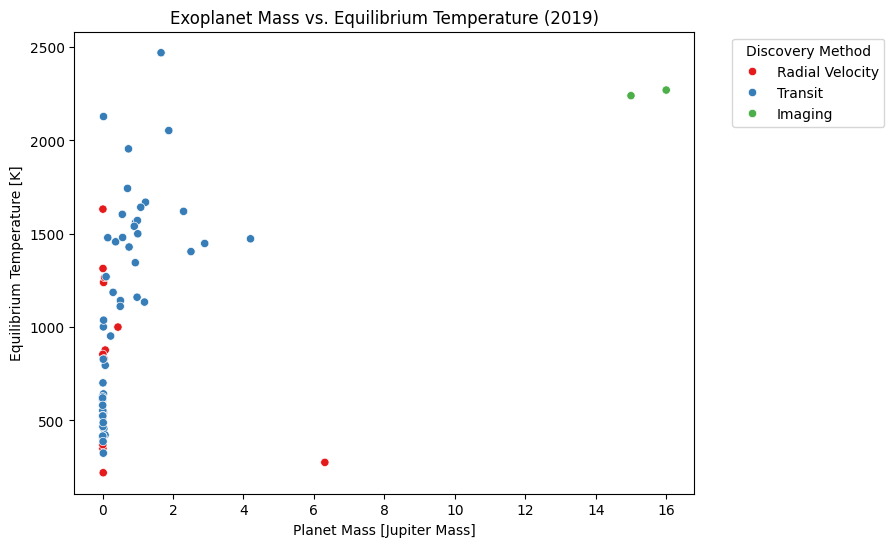

In [62]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df_reduced, x='pl_bmassj', y='pl_eqt', hue='discoverymethod', palette='Set1')

plt.title('Exoplanet Mass vs. Equilibrium Temperature (2019)')
plt.xlabel('Planet Mass [Jupiter Mass]')
plt.ylabel('Equilibrium Temperature [K]')
plt.legend(title='Discovery Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

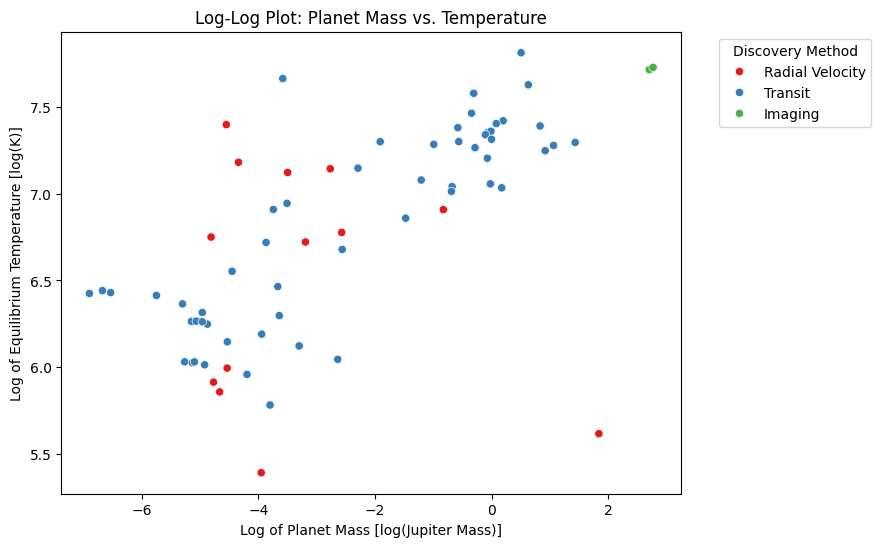

In [63]:
plt.figure(figsize=(8, 6))

df_log = df_reduced.copy()
df_log['log_mass'] = np.log(df_log['pl_bmassj'])
df_log['log_temp'] = np.log(df_log['pl_eqt'])

sns.scatterplot(data=df_log, x='log_mass', y='log_temp', hue='discoverymethod', palette='Set1')

plt.title('Log-Log Plot: Planet Mass vs. Temperature')
plt.xlabel('Log of Planet Mass [log(Jupiter Mass)]')
plt.ylabel('Log of Equilibrium Temperature [log(K)]')
plt.legend(title='Discovery Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [64]:
# 4. Based on the plot, the exoplanets found by the imaging method are much more likely to be massive.

In [65]:
# 5 & 6
heavy_planets = df_reduced[df_reduced['pl_bmassj'] > 5]
coldest_heavy_idx = heavy_planets['pl_eqt'].idxmin()
coldest_planet = df_reduced.loc[coldest_heavy_idx]
print(coldest_planet)

# Name: eps Ind A b
# Index: 581
# EQ Temp: 275.0 K
# Mass: 6.31 Jupiter Masses
# Star Type: K5 V, which is slightly smaller and cooler than the Sun, but is still a main-sequence star.

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object


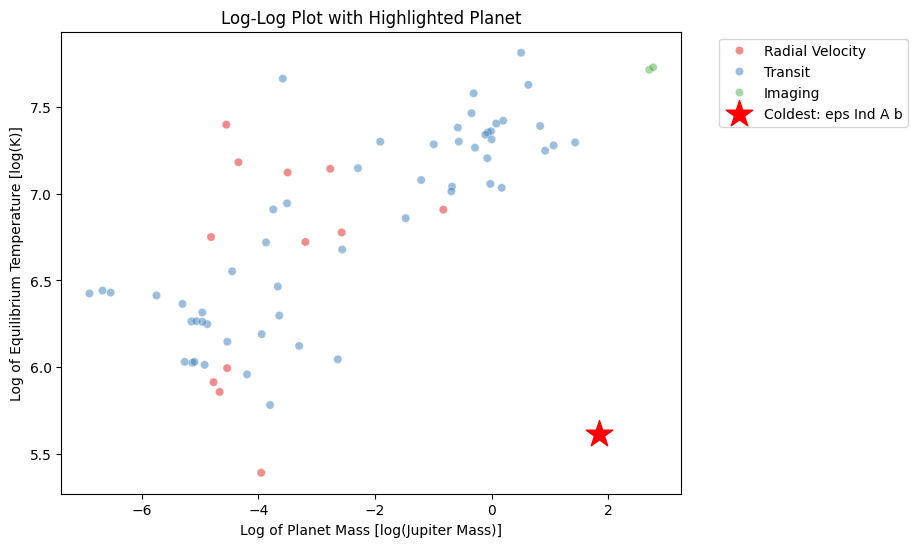

In [66]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_log, x='log_mass', y='log_temp', hue='discoverymethod', palette='Set1', alpha=0.5)

plt.scatter(df_log.loc[581, 'log_mass'], df_log.loc[581, 'log_temp'], 
            color='red', marker='*', s=400, label='Coldest: eps Ind A b')

plt.title('Log-Log Plot with Highlighted Planet')
plt.xlabel('Log of Planet Mass [log(Jupiter Mass)]')
plt.ylabel('Log of Equilibrium Temperature [log(K)]')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [67]:
# --- 4.5 Check Your Answer ---
'''
Title: A temperate super-Jupiter imaged with JWST in the mid-infrared.

Abstract Summary: Scientists used the James Webb Space Telescope to take a direct picture of a cold, Jupiter-like planet orbiting a nearby star. This is a big deal because most planets we've photographed are very young and hot, but this one is older and much colder, similar to our own solar system's gas giants.

Does it match? Yes, the paper is specifically about Eps Ind Ab, which is the same planet I found in the NASA Archive.

What is special? It is one of the coldest and oldest exoplanets ever to be directly imaged. Usually, we can only photograph "infant" planets that are still glowing with heat, but this one is "temperate" (relatively cool) and orbits a star similar in age to our Sun.

Do the mass and temperature match? Not exactly.

NASA Archive (My Data): Mass = 6.31 MJ, Temp = 275 K.

Nature Paper: Mass = 6.31 +0.58 MJ
                          −0.65

              Temp = 273±11 K

Differences: The values are very close, but the paper provides specific uncertainty ranges. The paper's temperature (273 K) is slightly lower than the 275 K listed in the archive. 
'''

'\nTitle: A temperate super-Jupiter imaged with JWST in the mid-infrared.\n\nAbstract Summary: Scientists used the James Webb Space Telescope to take a direct picture of a cold, Jupiter-like planet orbiting a nearby star. This is a big deal because most planets we\'ve photographed are very young and hot, but this one is older and much colder, similar to our own solar system\'s gas giants.\n\nDoes it match? Yes, the paper is specifically about Eps Ind Ab, which is the same planet I found in the NASA Archive.\n\nWhat is special? It is one of the coldest and oldest exoplanets ever to be directly imaged. Usually, we can only photograph "infant" planets that are still glowing with heat, but this one is "temperate" (relatively cool) and orbits a star similar in age to our Sun.\n\nDo the mass and temperature match? Not exactly.\n\nNASA Archive (My Data): Mass = 6.31 MJ, Temp = 275 K.\n\nNature Paper: Mass = 6.31 +0.58 MJ\n                          −0.65\n\n              Temp = 273±11 K\n\nDif